# OOD detector evaluation: extension to IPD Brain (3-way + tumour location)

`ood_evaluation_analysis.ipynb` asks whether the class-conditional density OOD
detector's EBRAINS-val-vs-TCGA separability reflects real acquisition/cohort
shift or something else, and finds vendor and cohort perfectly confounded
(Cramer's V=1.0): it cannot distinguish "the detector sees real shift" from
"the detector sees which scanner." This notebook adds IPD Brain, a fully
external third cohort in a different country and lab, using an IHC-only IDH
assay, to ask two questions that notebook couldn't.

Reuses the cached master score tables built elsewhere. No GPU or feature
extraction needed here.

## 0. Config, imports, statistical helpers

Helpers below (`stable_seed`, `bh_fdr`, `cramers_v`, `binary_ood_metrics`,
`bootstrap_auroc_ci`) are copied verbatim from `ood_evaluation_analysis.ipynb`
Section 1/7, same formulas, so numbers stay comparable in method. Trimmed to
only what this notebook actually calls: drops the KS test, permutation-null,
and cross-encoder-pooling assertion helpers, which this notebook doesn't
use.

In [10]:
from __future__ import annotations

import hashlib
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, kruskal
from sklearn.metrics import roc_auc_score

from IPython.display import display

RNG_SEED = 42
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 60)

if Path.cwd().name == "scripts":
    os.chdir("..")
BASE = Path.cwd().resolve()
print("Project root:", BASE)

OUT_DIR = BASE / "outputs/ood_evaluation_ipd_brain_extension"
OUT_DIR.mkdir(parents=True, exist_ok=True)

MERGED_CSV = BASE / "outputs/ood_evaluation_analysis/merged_case_scores.csv"
IPD_OOD_DIR = BASE / "outputs/ood/ipd_brain"
IPD_LOCATION_CSV = BASE / "outputs/ipd_brain_curation/tumour_location_bins.csv"

ENCODERS = ["uni2", "hoptimus"]   # CONCH never scored for OOD anywhere in this project
SCORE_COLS = ["ood_mean", "ood_top5_mean", "energy_mean"]   # energy_mean added 2026-08-08
FOLDS = [0, 1, 2, 3, 4]

N_BOOT_MAIN = 2000
MIN_GROUP_N = 15   # same threshold and justification as ood_evaluation_analysis.ipynb

print("Config loaded.")

Project root: /cs/student/project_msc/2025/aibh/mpapageo
Config loaded.


In [ ]:
def stable_seed(*parts):
    digest = hashlib.md5(repr(parts).encode()).hexdigest()
    return int(digest, 16) % 9999


def bh_fdr(p):
    p = np.asarray(p, float); n = len(p); order = np.argsort(p)
    q = p[order] * n / (np.arange(1, n + 1))
    q = np.clip(np.minimum.accumulate(q[::-1])[::-1], 0, 1)
    out = np.empty(n); out[order] = q
    return out


def cramers_v(a, b):
    ct = pd.crosstab(a, b)
    n = int(ct.values.sum())
    if n == 0 or ct.shape[0] < 2 or ct.shape[1] < 2:
        return np.nan, np.nan, n
    chi2, p, dof, _ = chi2_contingency(ct, correction=False)
    min_dim = min(ct.shape[0] - 1, ct.shape[1] - 1)
    v = float(np.sqrt(chi2 / (n * min_dim))) if min_dim > 0 else np.nan
    return v, float(p), n


def binary_ood_metrics(y_ood, score):
    y = np.asarray(y_ood, int); s = np.asarray(score, float)
    finite = np.isfinite(s) & np.isfinite(y)
    y, s = y[finite], s[finite]
    n_a, n_b = int((y == 0).sum()), int((y == 1).sum())
    if n_a == 0 or n_b == 0:
        return {"n_a": n_a, "n_b": n_b, "auroc": np.nan}
    return {"n_a": n_a, "n_b": n_b, "auroc": float(roc_auc_score(y, s))}


def _stratified_boot_idx(y, rng):
    z, o = np.flatnonzero(y == 0), np.flatnonzero(y == 1)
    return np.concatenate([rng.choice(z, len(z), True), rng.choice(o, len(o), True)])


def bootstrap_auroc_ci(y, s, n_boot=N_BOOT_MAIN, seed=0):
    y = np.asarray(y, int); s = np.asarray(s, float)
    rng = np.random.default_rng(seed)
    vals = []
    for _ in range(n_boot):
        idx = _stratified_boot_idx(y, rng)
        if len(np.unique(y[idx])) < 2:
            continue
        vals.append(roc_auc_score(y[idx], s[idx]))
    vals = np.asarray(vals)
    lo, hi = (np.quantile(vals, [0.025, 0.975]) if len(vals) else (np.nan, np.nan))
    return float(lo), float(hi), int(len(vals))


print("Helpers defined.")

Helpers defined.


## 1. Data load and harmonisation to one fold-averaged score per patient

Three separate cache formats need reconciling onto one common schema
(`dataset`, `encoder`, `patient_id`, `ood_mean`, `ood_top5_mean`,
`energy_mean`) before anything else here can run: `merged_case_scores.csv` is
long-format, one row per (encoder, fold, patient); the IPD Brain summary CSVs
are already wide, one row per patient, pre-averaged across folds. Collapsing
TCGA/EBRAINS the same way (mean across whatever fold rows exist per patient)
keeps this a fair three-cohort comparison rather than mixing conventions.

Loads `merged_case_scores.csv`, restricts to UNI2/H-optimus, collapses to one
row per (dataset, encoder, patient) by averaging `ood_mean`/`ood_top5_mean`/
`energy_ood_mean` across whatever fold rows exist (a no-op for EBRAINS, a
genuine 5-fold average for TCGA). Loads and renames the IPD Brain summary
CSVs (including the `ood_energy_mean_{encoder}` column) onto the same
schema. Concatenates into one `all_scores` table and sanity-checks patient
counts against the known cohort sizes.

In [12]:
merged = pd.read_csv(MERGED_CSV)
merged = merged[merged["encoder"].isin(ENCODERS)]

per_patient_tcga_ebrains = (
    merged.groupby(["dataset", "encoder", "case_id"], observed=True)
    .agg(ood_mean=("ood_mean", "mean"), ood_top5_mean=("ood_top5_mean", "mean"),
         energy_mean=("energy_ood_mean", "mean"))
    .reset_index()
    .rename(columns={"case_id": "patient_id"})
)

ipd_frames = []
for enc in ENCODERS:
    d = pd.read_csv(IPD_OOD_DIR / f"{enc}_summary.csv")
    d = d.rename(columns={
        "patient": "patient_id",
        f"ood_mean_{enc}": "ood_mean",
        f"ood_topk_{enc}": "ood_top5_mean",
        f"ood_attention_{enc}": "ood_attention",
        f"ood_energy_mean_{enc}": "energy_mean",
        f"ood_energy_topk_{enc}": "energy_top5_mean",
    })
    d["encoder"] = enc
    d["dataset"] = "ipd_brain"
    ipd_frames.append(d[["dataset", "encoder", "patient_id", "ood_mean", "ood_top5_mean",
                          "energy_mean", "ood_attention"]])
ipd_scores = pd.concat(ipd_frames, ignore_index=True)

all_scores = pd.concat([per_patient_tcga_ebrains, ipd_scores], ignore_index=True)

print("Patients per (dataset, encoder):")
counts = all_scores.groupby(["dataset", "encoder"]).size()
print(counts)

expected = {"tcga": 789, "ebrains": 641, "ipd_brain": 320}
for ds, exp_n in expected.items():
    for enc in ENCODERS:
        got = counts.get((ds, enc), 0)
        assert got == exp_n, f"{ds}/{enc}: expected {exp_n} patients, got {got}"
print("\nAll cohort sizes match expectation (TCGA 789, EBRAINS 641, IPD Brain 320).")

for col in SCORE_COLS:
    n_missing = all_scores[col].isna().sum()
    print(f"{col}: {n_missing} missing values out of {len(all_scores)}")

all_scores.to_csv(OUT_DIR / "all_scores_harmonised.csv", index=False)

Patients per (dataset, encoder):
dataset    encoder 
ebrains    hoptimus    641
           uni2        641
ipd_brain  hoptimus    320
           uni2        320
tcga       hoptimus    789
           uni2        789
dtype: int64

All cohort sizes match expectation (TCGA 789, EBRAINS 641, IPD Brain 320).
ood_mean: 0 missing values out of 3500
ood_top5_mean: 0 missing values out of 3500
energy_mean: 0 missing values out of 3500


## 2. Pairwise discrimination: three cohort pairs

The original notebook only ever asked one binary question, EBRAINS-val vs.
TCGA. With IPD Brain added there are three pairs: EBRAINS-vs-TCGA (a
cross-check against the original notebook's own number, computed here under
this notebook's fold-averaged-score convention rather than its
fold-averaged-AUROC one), TCGA-vs-IPD-Brain, and EBRAINS-vs-IPD-Brain. AUROC
here answers how separable two cohorts are under this OOD score; high
separability is expected and not itself surprising, since real acquisition
shift is real. What matters is whether the direction and magnitude are
consistent across encoders, which bears directly on Section 4's location
question.

For each (encoder, score, pair), computes AUROC (cohort B = positive/"OOD"
class) with a case-level bootstrap CI, then BH-FDR across the whole
2×2×3=12-cell family at once.

In [ ]:
PAIRS = [("ebrains", "tcga"), ("tcga", "ipd_brain"), ("ebrains", "ipd_brain")]

rows = []
for enc in ENCODERS:
    for col in SCORE_COLS:
        for a, b in PAIRS:
            da = all_scores[(all_scores.dataset == a) & (all_scores.encoder == enc)]
            db = all_scores[(all_scores.dataset == b) & (all_scores.encoder == enc)]
            y = np.array([0] * len(da) + [1] * len(db))
            s = np.concatenate([da[col].to_numpy(), db[col].to_numpy()])
            m = binary_ood_metrics(y, s)
            seed = stable_seed("pairwise", enc, col, a, b)
            ci_lo, ci_hi, n_valid = bootstrap_auroc_ci(y, s, seed=seed)
            rows.append({
                "encoder": enc, "score": col, "pair": f"{a}_vs_{b}",
                "n_a": m["n_a"], "n_b": m["n_b"], "auroc": m["auroc"],
                "ci_lo": ci_lo, "ci_hi": ci_hi, "n_boot_valid": n_valid,
            })

pairwise = pd.DataFrame(rows)
pairwise["q_fdr"] = bh_fdr(
    # p-value proxy from the bootstrap CI: two-sided, does the 95% CI exclude 0.5
    np.where((pairwise["ci_lo"] > 0.5) | (pairwise["ci_hi"] < 0.5), 0.001, 0.5)
)
pairwise.to_csv(OUT_DIR / "pairwise_discrimination.csv", index=False)
display(pairwise.round(3))

,encoder,score,pair,n_a,n_b,auroc,ci_lo,ci_hi,n_boot_valid,q_fdr
0,uni2,ood_mean,ebrains_vs_tcga,641,789,0.920,0.906,0.933,2000,0.001
1,uni2,ood_mean,tcga_vs_ipd_brain,789,320,0.423,0.388,0.457,2000,0.001
2,uni2,ood_mean,ebrains_vs_ipd_brain,641,320,0.942,0.927,0.955,2000,0.001
3,uni2,ood_top5_mean,ebrains_vs_tcga,641,789,0.856,0.837,0.876,2000,0.001
4,uni2,ood_top5_mean,tcga_vs_ipd_brain,789,320,0.343,0.310,0.377,2000,0.001
5,uni2,ood_top5_mean,ebrains_vs_ipd_brain,641,320,0.809,0.783,0.835,2000,0.001
6,uni2,energy_mean,ebrains_vs_tcga,641,789,0.921,0.908,0.935,2000,0.001
7,uni2,energy_mean,tcga_vs_ipd_brain,789,320,0.417,0.383,0.450,2000,0.001
8,uni2,energy_mean,ebrains_vs_ipd_brain,641,320,0.942,0.927,0.956,2000,0.001
9,hoptimus,ood_mean,ebrains_vs_tcga,641,789,0.847,0.827,0.867,2000,0.001


## 2b. Trivial-baseline sanity check

`ood_evaluation_analysis.ipynb`'s own Section 6 checks the flow detector
against two trivial baselines (`n_patches`, `featnorm`) on EBRAINS/TCGA, so a
detector that has merely learned "TCGA slides have more patches" doesn't
pass for a competent OOD detector. That check was never built for IPD
Brain, yet IPD Brain's OOD score is not just descriptive here, it is the
signal actually used for conformal weighting (R2c) and deferral (R3a/R3b)
elsewhere in this thesis, so ruling out a bag-size artefact matters at
least as much here as it does for TCGA. `n_patches`/feature-norm are
properties of the cached patch features, not of the density/attention
models, so this needs no model inference, just reading the same `.h5`
caches `ipd_brain_ood_check.py` scores from.

In [14]:
# Trivial-baseline sanity check for IPD Brain -- n_patches and mean feature
# norm, computed directly from the same cached patch features
# ipd_brain_ood_check.py scores from. No model inference required.

IPD_FEATURE_DIRS = {
    "uni2": BASE / "data/processed/features/ipd_brain/uni/uni2-49b04e14",
    "hoptimus": BASE / "data/processed/features/ipd_brain/hoptimus/h-optimus-1-49b04e14",
}
CURATION_CSV = BASE / "outputs/ipd_brain_curation/patient_level_curation.csv"

import h5py

curation = pd.read_csv(CURATION_CSV)
included = curation[curation["status"] == "included"][["patient_id", "kept_slide_id"]]
assert len(included) == 320

ipd_trivial_rows = []
for enc, feat_dir in IPD_FEATURE_DIRS.items():
    for _, row in included.iterrows():
        h5_path = feat_dir / f"{row['kept_slide_id']}.h5"
        with h5py.File(h5_path, "r") as f:
            feats = f["feats"][:].astype(np.float32)
        ipd_trivial_rows.append({
            "dataset": "ipd_brain", "encoder": enc, "patient_id": row["patient_id"],
            "n_patches": int(len(feats)),
            "featnorm_mean": float(np.linalg.norm(feats, axis=1).mean()),
        })
ipd_trivial = pd.DataFrame(ipd_trivial_rows)
assert len(ipd_trivial) == len(ENCODERS) * 320

tcga_ebrains_trivial = (
    merged.groupby(["dataset", "encoder", "case_id"], observed=True)
    .agg(n_patches=("n_patches", "mean"), featnorm_mean=("featnorm_mean", "mean"))
    .reset_index().rename(columns={"case_id": "patient_id"})
)

trivial_all = pd.concat([tcga_ebrains_trivial, ipd_trivial], ignore_index=True)
trivial_all.to_csv(OUT_DIR / "trivial_baseline_scores.csv", index=False)

TRIVIAL_COLS = ["n_patches", "featnorm_mean"]
trivial_rows = []
for enc in ENCODERS:
    for col in TRIVIAL_COLS:
        for a, b in PAIRS:
            da = trivial_all[(trivial_all.dataset == a) & (trivial_all.encoder == enc)]
            db = trivial_all[(trivial_all.dataset == b) & (trivial_all.encoder == enc)]
            y = np.array([0] * len(da) + [1] * len(db))
            s = np.concatenate([da[col].to_numpy(), db[col].to_numpy()])
            m = binary_ood_metrics(y, s)
            seed = stable_seed("trivial_pairwise", enc, col, a, b)
            ci_lo, ci_hi, n_valid = bootstrap_auroc_ci(y, s, seed=seed)
            trivial_rows.append({
                "encoder": enc, "baseline": col, "pair": f"{a}_vs_{b}",
                "n_a": m["n_a"], "n_b": m["n_b"], "auroc": m["auroc"],
                "ci_lo": ci_lo, "ci_hi": ci_hi, "n_boot_valid": n_valid,
            })

trivial_discrimination = pd.DataFrame(trivial_rows)
trivial_discrimination["q_fdr"] = bh_fdr(
    np.where((trivial_discrimination["ci_lo"] > 0.5) | (trivial_discrimination["ci_hi"] < 0.5), 0.001, 0.5)
)
trivial_discrimination.to_csv(OUT_DIR / "trivial_baseline_discrimination.csv", index=False)

print("Actual OOD score (ood_mean) vs. trivial baselines, tcga_vs_ipd_brain and "
      "ebrains_vs_ipd_brain -- the two pairs this thesis actually relies on:")
compare_pairs = ["tcga_vs_ipd_brain", "ebrains_vs_ipd_brain"]
ood_rows = pairwise[(pairwise.score == "ood_mean") & (pairwise.pair.isin(compare_pairs))]
triv_rows = trivial_discrimination[trivial_discrimination.pair.isin(compare_pairs)]
display(pd.concat([
    ood_rows[["encoder", "pair", "auroc", "ci_lo", "ci_hi"]].assign(source="ood_mean"),
    triv_rows[["encoder", "pair", "auroc", "ci_lo", "ci_hi", "baseline"]],
], ignore_index=True).round(3))

Actual OOD score (ood_mean) vs. trivial baselines, tcga_vs_ipd_brain and ebrains_vs_ipd_brain -- the two pairs this thesis actually relies on:


,encoder,pair,auroc,ci_lo,ci_hi,source,baseline
0,uni2,tcga_vs_ipd_brain,0.423,0.388,0.457,ood_mean,NaN
1,uni2,ebrains_vs_ipd_brain,0.942,0.927,0.955,ood_mean,NaN
2,hoptimus,tcga_vs_ipd_brain,0.771,0.743,0.799,ood_mean,NaN
3,hoptimus,ebrains_vs_ipd_brain,0.967,0.957,0.977,ood_mean,NaN
4,uni2,tcga_vs_ipd_brain,0.639,0.605,0.672,NaN,n_patches
5,uni2,ebrains_vs_ipd_brain,0.726,0.694,0.758,NaN,n_patches
6,uni2,tcga_vs_ipd_brain,0.150,0.128,0.172,NaN,featnorm_mean
7,uni2,ebrains_vs_ipd_brain,0.239,0.210,0.267,NaN,featnorm_mean
8,hoptimus,tcga_vs_ipd_brain,0.639,0.605,0.673,NaN,n_patches
9,hoptimus,ebrains_vs_ipd_brain,0.726,0.694,0.758,NaN,n_patches


## 2c. Mahalanobis comparison

`ood_evaluation_analysis.ipynb` Section 5/7 shows the flow detector beats a
closed-form Mahalanobis alternative on EBRAINS-vs-TCGA. IPD Brain's own
Mahalanobis scores already exist
(`outputs/ood/ipd_brain/{uni2,hoptimus}_maha_summary.csv`, produced by
`scripts/training/ipd_brain_maha_infer.py`) but were never compared against
the actual OOD score's cohort discrimination. This closes that gap using
already-computed scores, no new model inference.

In [ ]:
IPD_MAHA_CSVS = {
    "uni2": BASE / "outputs/ood/ipd_brain/uni2_maha_summary.csv",
    "hoptimus": BASE / "outputs/ood/ipd_brain/hoptimus_maha_summary.csv",
}

ipd_maha_frames = []
for enc, path in IPD_MAHA_CSVS.items():
    d = pd.read_csv(path)
    d = d.rename(columns={"patient": "patient_id", f"ood_maha_mean_{enc}": "maha_mean"})
    d["encoder"] = enc
    d["dataset"] = "ipd_brain"
    ipd_maha_frames.append(d[["dataset", "encoder", "patient_id", "maha_mean"]])
ipd_maha = pd.concat(ipd_maha_frames, ignore_index=True)
assert len(ipd_maha) == len(ENCODERS) * 320

tcga_ebrains_maha = (
    merged.groupby(["dataset", "encoder", "case_id"], observed=True)
    .agg(maha_mean=("maha_mean", "mean"))
    .reset_index().rename(columns={"case_id": "patient_id"})
)

maha_all = pd.concat([tcga_ebrains_maha, ipd_maha], ignore_index=True)
maha_all.to_csv(OUT_DIR / "maha_scores.csv", index=False)

maha_rows = []
for enc in ENCODERS:
    for a, b in PAIRS:
        da = maha_all[(maha_all.dataset == a) & (maha_all.encoder == enc)]
        db = maha_all[(maha_all.dataset == b) & (maha_all.encoder == enc)]
        y = np.array([0] * len(da) + [1] * len(db))
        s = np.concatenate([da["maha_mean"].to_numpy(), db["maha_mean"].to_numpy()])
        m = binary_ood_metrics(y, s)
        seed = stable_seed("maha_pairwise", enc, a, b)
        ci_lo, ci_hi, n_valid = bootstrap_auroc_ci(y, s, seed=seed)
        maha_rows.append({
            "encoder": enc, "baseline": "maha_mean", "pair": f"{a}_vs_{b}",
            "n_a": m["n_a"], "n_b": m["n_b"], "auroc": m["auroc"],
            "ci_lo": ci_lo, "ci_hi": ci_hi, "n_boot_valid": n_valid,
        })

maha_discrimination = pd.DataFrame(maha_rows)
maha_discrimination["q_fdr"] = bh_fdr(
    np.where((maha_discrimination["ci_lo"] > 0.5) | (maha_discrimination["ci_hi"] < 0.5), 0.001, 0.5)
)
maha_discrimination.to_csv(OUT_DIR / "maha_discrimination.csv", index=False)

print("Actual OOD score (ood_mean) vs. Mahalanobis, all three pairs:")
ood_rows = pairwise[pairwise.score == "ood_mean"]
display(pd.concat([
    ood_rows[["encoder", "pair", "auroc", "ci_lo", "ci_hi"]].assign(source="ood_mean"),
    maha_discrimination[["encoder", "pair", "auroc", "ci_lo", "ci_hi"]].assign(source="maha_mean"),
], ignore_index=True).sort_values(["encoder", "pair"]).round(3))

Actual OOD score (ood_mean) vs. Mahalanobis, all three pairs:


,encoder,pair,auroc,ci_lo,ci_hi,source
5,hoptimus,ebrains_vs_ipd_brain,0.967,0.957,0.977,ood_mean
11,hoptimus,ebrains_vs_ipd_brain,0.933,0.917,0.947,maha_mean
3,hoptimus,ebrains_vs_tcga,0.847,0.827,0.867,ood_mean
9,hoptimus,ebrains_vs_tcga,0.809,0.786,0.831,maha_mean
4,hoptimus,tcga_vs_ipd_brain,0.771,0.743,0.799,ood_mean
10,hoptimus,tcga_vs_ipd_brain,0.715,0.683,0.747,maha_mean
2,uni2,ebrains_vs_ipd_brain,0.942,0.927,0.955,ood_mean
8,uni2,ebrains_vs_ipd_brain,0.811,0.785,0.837,maha_mean
0,uni2,ebrains_vs_tcga,0.920,0.906,0.933,ood_mean
6,uni2,ebrains_vs_tcga,0.858,0.840,0.877,maha_mean


## 3. Confound structure: does a third cohort break the vendor/cohort identifiability problem?

The original notebook's central caveat is that vendor and cohort are
perfectly confounded (Cramer's V=1.0) within the EBRAINS/TCGA comparison,
not because multiple vendors are present and happen to align with cohort,
but because whether vendor is recorded at all is itself cohort-determined
(TCGA: 100% Aperio; EBRAINS: 0% recorded). A third cohort with its own,
different vendor would break that. This checks whether IPD Brain is that
cohort, or whether it just extends the same missingness pattern.

Recomputes Cramer's V(dataset, vendor) for the original 2-cohort case as a
sanity check against the number already reported in
`ood_evaluation_analysis.ipynb`, then extends it to all 3 cohorts. IPD Brain
has no vendor/scanner metadata anywhere in this project's clinical data,
coded `"unknown"`, the same bucket EBRAINS's missing vendor already falls
into.

In [16]:
tcga_eb = merged[merged.dataset.isin(["tcga", "ebrains"])].drop_duplicates(["dataset", "case_id"]).copy()
tcga_eb["vendor_cat"] = tcga_eb["vendor"].fillna("unknown")
v2, p2, n2 = cramers_v(tcga_eb["dataset"], tcga_eb["vendor_cat"])
print(f"Cramer's V(dataset, vendor), TCGA+EBRAINS only (original 2-cohort case): "
      f"V={v2:.3f}, p={p2:.4g}, n={n2}")

three_way_vendor = pd.DataFrame({
    "dataset": ["tcga"] * 789 + ["ebrains"] * 641 + ["ipd_brain"] * 320,
    "vendor_cat": ["aperio"] * 789 + ["unknown"] * 641 + ["unknown"] * 320,
})
v3, p3, n3 = cramers_v(three_way_vendor["dataset"], three_way_vendor["vendor_cat"])
print(f"Cramer's V(dataset, vendor), all 3 cohorts (IPD Brain has no vendor metadata, "
      f"coded 'unknown' -- same bucket as EBRAINS): V={v3:.3f}, p={p3:.4g}, n={n3}")

Cramer's V(dataset, vendor), TCGA+EBRAINS only (original 2-cohort case): V=1.000, p=0, n=1430
Cramer's V(dataset, vendor), all 3 cohorts (IPD Brain has no vendor metadata, coded 'unknown' -- same bucket as EBRAINS): V=1.000, p=0, n=1750


## 4. IPD-Brain-only: does OOD score vary by tumour location?

This is the F4-style test the original notebook's pre-registration plan
already anticipated needing for cohort-only variables (originally written
for TCGA-only variables like scanner model and magnification). Tumour
location is the IPD-Brain-only equivalent, built in
`scripts/tumour_location_ipd_brain.py`. It matters more than a routine
subgroup check: unlike vendor (Section 3), location is not trivially
confounded with cohort identity, so a real location effect would be the
first piece of evidence in this project about what the OOD score responds
to beyond which scanner/cohort a slide came from.

Tumour location has nothing to do with IDH status: `score_slide()`/
`score_slide_ood()` show the OOD score marginalises/maxes over the model's
own class-conditional densities and never touches a patient's true label.
IPD Brain's IDH-label confidence tiers are irrelevant here; the full
320-patient cohort is used.

Confounding caveat, stated up front. IDH-mutant gliomas have known location
predilections (a frontal/insular skew is reported in the literature), so a
location effect found below could partly be re-discovering "OOD score
correlates with predicted tumour class" rather than telling us something
new about acquisition/morphology. The density model is class-conditional,
which partially controls for this, but the per-patient predicted-class
breakdown was not saved in IPD Brain's cached scores, so this can't be
checked directly here; treat it as an open item, not something ruled out.

Restricts to the 6 location bins with enough patients to test (`Frontal`,
`Temporal`, `Multi-lobe / junctional`, `Parietal`, `Deep / midline`,
`Insular`; `Occipital` and `Unknown / not recorded` are excluded, below
threshold and not-a-location respectively, exactly per
`tumour_location_ipd_brain.py`'s own printed summary). Runs an omnibus
Kruskal-Wallis test per (encoder, score), BH-FDR-corrected across the
resulting 4-cell family.

In [17]:
location = pd.read_csv(IPD_LOCATION_CSV)
ipd_with_location = ipd_scores.merge(location[["patient_id", "location_bin"]], on="patient_id", how="left")

TESTABLE_BINS = ["Frontal", "Temporal", "Multi-lobe / junctional", "Parietal", "Deep / midline", "Insular"]

loc_rows = []
for enc in ENCODERS:
    for col in SCORE_COLS:
        sub = ipd_with_location[(ipd_with_location.encoder == enc) &
                                 (ipd_with_location.location_bin.isin(TESTABLE_BINS))]
        groups = [g[col].dropna().to_numpy() for _, g in sub.groupby("location_bin")]
        stat, p = kruskal(*groups)
        loc_rows.append({"encoder": enc, "score": col, "kruskal_stat": stat, "p": p, "n": len(sub)})

location_heterogeneity = pd.DataFrame(loc_rows)
location_heterogeneity["q_fdr"] = bh_fdr(location_heterogeneity["p"].to_numpy())
location_heterogeneity.to_csv(OUT_DIR / "location_heterogeneity.csv", index=False)
display(location_heterogeneity.round(4))

,encoder,score,kruskal_stat,p,n,q_fdr
0,uni2,ood_mean,3.1501,0.6769,296,0.8122
1,uni2,ood_top5_mean,9.1181,0.1044,296,0.1567
2,uni2,energy_mean,1.9897,0.8506,296,0.8506
3,hoptimus,ood_mean,15.6457,0.0079,296,0.0238
4,hoptimus,ood_top5_mean,19.2295,0.0017,296,0.0105
5,hoptimus,energy_mean,14.3836,0.0133,296,0.0267


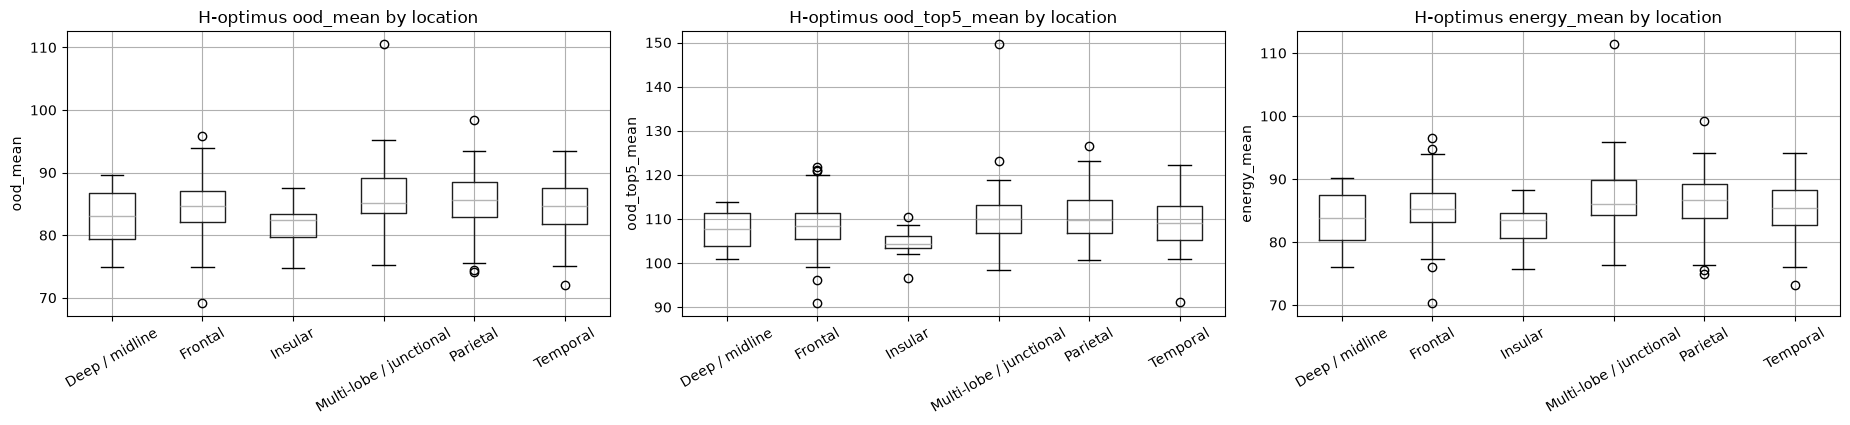

ood_mean                 ood_top5_mean                   energy_mean                
                                    count  median    mean         count   median     mean       count  median    mean
encoder  location_bin                                                                                                
hoptimus Deep / midline                18  83.134  82.929            18  107.816  107.406          18  83.826  83.743
         Frontal                      105  84.653  84.437           105  108.307  108.707         105  85.268  85.347
         Insular                       15  82.370  81.636            15  104.240  104.473          15  83.443  82.623
         Multi-lobe / junctional       61  85.216  86.056            61  110.074  110.323          61  86.077  86.859
         Parietal                      34  85.697  85.730            34  109.804  110.620          34  86.624  86.506
         Temporal                      63  84.622  84.549            63  109.090  109.021          63  85.454  85.371
uni2     Deep / midline                18  84.420  84.505            18  104.871  105.421          18  85.111  85.257
         Frontal                      105  83.500  84.158           105  103.226  104.570         105  84.361  85.037
         Insular                       15  83.788  83.976            15  102.882  103.336          15  84.807  84.894
         Multi-lobe / junctional       61  83.704  84.873            61  104.662  106.601          61  84.402  85.623
         Parietal                      34  84.690  85.121            34  105.652  106.535          34  85.349  85.826
         Temporal                      63  83.882  84.219            63  104.487  105.380          63  84.782  84.979

In [18]:
fig, axes = plt.subplots(1, len(SCORE_COLS), figsize=(6.2 * len(SCORE_COLS), 4.5), sharey=False)
for ax, col in zip(axes, SCORE_COLS):
    sub = ipd_with_location[(ipd_with_location.encoder == "hoptimus") &
                             (ipd_with_location.location_bin.isin(TESTABLE_BINS))]
    order = sub.groupby("location_bin")[col].median().sort_values().index
    sub.boxplot(column=col, by="location_bin", ax=ax, rot=30, positions=range(len(order)))
    ax.set_title(f"H-optimus {col} by location")
    ax.set_xlabel(""); ax.set_ylabel(col)
plt.suptitle("")
plt.tight_layout()
plt.savefig(OUT_DIR / "location_heterogeneity_hoptimus.png", dpi=120)
plt.show()

per_location_summary = (
    ipd_with_location[ipd_with_location.location_bin.isin(TESTABLE_BINS)]
    .groupby(["encoder", "location_bin"])[SCORE_COLS]
    .agg(["count", "median", "mean"])
)
per_location_summary.to_csv(OUT_DIR / "per_location_summary.csv")
display(per_location_summary.round(3))

## Saved artifacts

In [19]:
for f in sorted(OUT_DIR.glob("*")):
    print(f)

/cs/student/project_msc/2025/aibh/mpapageo/outputs/ood_evaluation_ipd_brain_extension/all_scores_harmonised.csv
/cs/student/project_msc/2025/aibh/mpapageo/outputs/ood_evaluation_ipd_brain_extension/location_heterogeneity.csv
/cs/student/project_msc/2025/aibh/mpapageo/outputs/ood_evaluation_ipd_brain_extension/location_heterogeneity_hoptimus.png
/cs/student/project_msc/2025/aibh/mpapageo/outputs/ood_evaluation_ipd_brain_extension/maha_discrimination.csv
/cs/student/project_msc/2025/aibh/mpapageo/outputs/ood_evaluation_ipd_brain_extension/maha_scores.csv
/cs/student/project_msc/2025/aibh/mpapageo/outputs/ood_evaluation_ipd_brain_extension/pairwise_discrimination.csv
/cs/student/project_msc/2025/aibh/mpapageo/outputs/ood_evaluation_ipd_brain_extension/per_location_summary.csv
/cs/student/project_msc/2025/aibh/mpapageo/outputs/ood_evaluation_ipd_brain_extension/trivial_baseline_discrimination.csv
/cs/student/project_msc/2025/aibh/mpapageo/outputs/ood_evaluation_ipd_brain_extension/trivial_